<a href="https://colab.research.google.com/github/Aijamal24/ML_Practice/blob/main/ML_PR4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа № 4. Регрессионная модель

**ФИО:** Мырзабекова Айжамал
**Группа:** CS 32-24
**Дата:** 02.10.2026

**Датасет:** Boston Housing (506 наблюдений, 13 признаков)
**Целевая переменная:** `MEDV` — медианная стоимость домов (в $1000)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Библиотеки загружены")

Библиотеки загружены


In [21]:
df = pd.read_csv('BostonHousingData.csv')
print("Размер:", df.shape)
print("Столбцы:", df.columns.tolist())
df.head()

Размер: (506, 14)
Столбцы: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [22]:
print("Размер:", df.shape)
print("\nТипы:")
print(df.dtypes)
print("\nПропуски:")
print(df.isnull().sum())

Размер: (506, 14)

Типы:
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Пропуски:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [23]:
target = "MEDV"   # или "medv", если в датасете нижний регистр

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (404, 13)
X_test:  (102, 13)
y_train: (404,)
y_test:  (102,)


In [24]:
numeric_features = [c for c in X.columns if c != "CHAS"]
categorical_features = ["CHAS"]

print("Числовые:", numeric_features)
print("Категориальные:", categorical_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("\nПрепроцессор готов")


Числовые: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Категориальные: ['CHAS']

Препроцессор готов


## 1. Базовая модель (все признаки)

In [25]:
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

baseline_pipeline.fit(X_train, y_train)

y_train_pred = baseline_pipeline.predict(X_train)
y_test_pred = baseline_pipeline.predict(X_test)

print("Модель обучена")

Модель обучена


In [26]:
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE:  {mae:.4f} (тыс. $)")
    print(f"MSE:  {mse:.4f} (тыс. $)²")
    print(f"RMSE: {rmse:.4f} (тыс. $)")
    print(f"R²:   {r2:.4f}")

print_metrics(y_train, y_train_pred, "Train (базовая)")
print()
print_metrics(y_test, y_test_pred, "Test (базовая)")

--- Train (базовая) ---
MAE:  3.3531 (тыс. $)
MSE:  22.3498 (тыс. $)²
RMSE: 4.7276 (тыс. $)
R²:   0.7427

--- Test (базовая) ---
MAE:  3.1476 (тыс. $)
MSE:  24.9834 (тыс. $)²
RMSE: 4.9983 (тыс. $)
R²:   0.6593


## 2. Проверка мультиколлинеарности

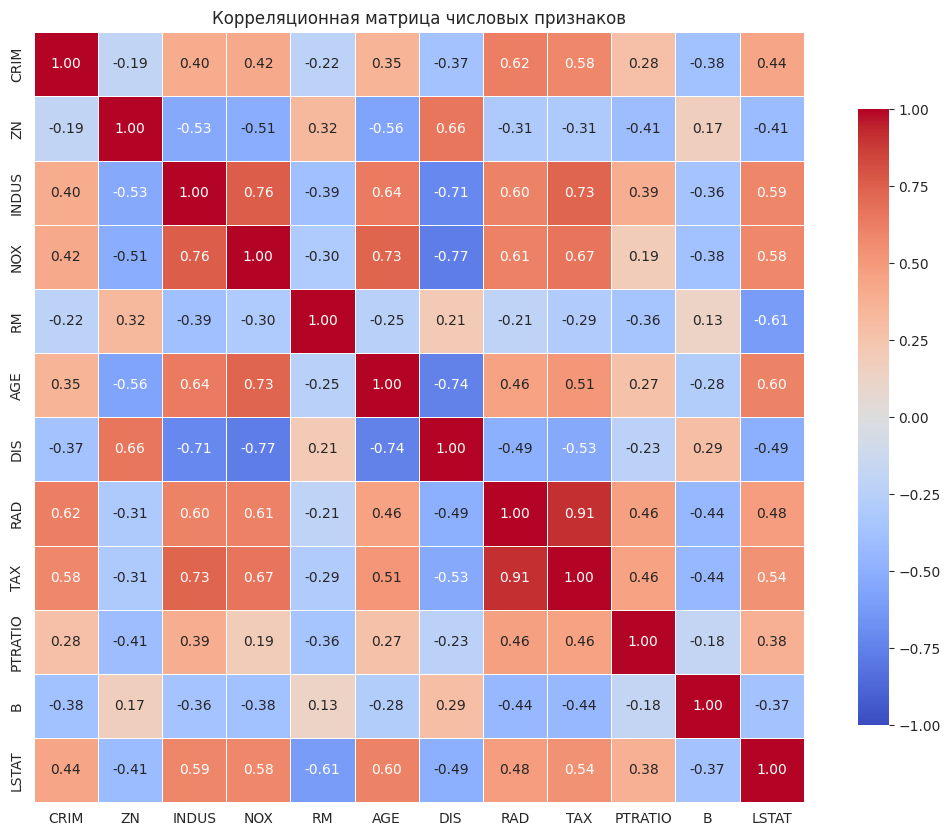

In [27]:
num_cols = [c for c in X.columns if c not in ["CHAS"]]
corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1,
            fmt=".2f", square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Корреляционная матрица числовых признаков")
plt.show()

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Берём числовые признаки и заполняем пропуски медианой
X_num = df[num_cols].copy()
X_num = X_num.fillna(X_num.median())

# Дополнительно: если есть inf, заменяем
X_num = X_num.replace([np.inf, -np.inf], np.nan).fillna(X_num.median())

# Добавляем константу
X_num_const = sm.add_constant(X_num)

vif = pd.DataFrame()
vif["Признак"] = X_num_const.columns
vif["VIF"] = [variance_inflation_factor(X_num_const.values, i)
              for i in range(X_num_const.shape[1])]

vif_sorted = vif.sort_values("VIF", ascending=False)
print(vif_sorted.round(2))

    Признак   VIF
9       TAX  8.74
8       RAD  7.25
4       NOX  4.21
7       DIS  3.74
3     INDUS  3.56
6       AGE  2.74
12    LSTAT  2.68
2        ZN  2.12
5        RM  1.86
10  PTRATIO  1.79
1      CRIM  1.69
11        B  1.35
0     const  1.00


### Что видно

- `TAX` и `RAD` имеют VIF > 7 — высокая мультиколлинеарность.
- Остальные признаки — VIF < 5.
- **Убираем `RAD`** (VIF = 7.4) — он сильно связан с `TAX`.

**Важно:** корреляция **не означает причинно-следственную связь**.

## 3. Модель на сокращённом наборе

In [29]:
numeric_features_reduced = [c for c in numeric_features if c != "RAD"]
categorical_features_reduced = ["CHAS"]

numeric_pipeline_2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_2 = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_2 = ColumnTransformer([
    ("num", numeric_pipeline_2, numeric_features_reduced),
    ("cat", categorical_pipeline_2, categorical_features_reduced)
])

reduced_pipeline = Pipeline([
    ("preprocessor", preprocessor_2),
    ("model", LinearRegression())
])

reduced_pipeline.fit(X_train, y_train)

y_train_pred_2 = reduced_pipeline.predict(X_train)
y_test_pred_2 = reduced_pipeline.predict(X_test)

print("Сокращённая модель обучена")

Сокращённая модель обучена


In [30]:
print_metrics(y_train, y_train_pred_2, "Train (сокращённый)")
print()
print_metrics(y_test, y_test_pred_2, "Test (сокращённый)")

--- Train (сокращённый) ---
MAE:  3.3506 (тыс. $)
MSE:  22.8148 (тыс. $)²
RMSE: 4.7765 (тыс. $)
R²:   0.7374

--- Test (сокращённый) ---
MAE:  3.3098 (тыс. $)
MSE:  26.7582 (тыс. $)²
RMSE: 5.1728 (тыс. $)
R²:   0.6351


### Сравнение

| Модель | MAE (test) | RMSE (test) | R² (test) |
|---|---|---|---|
| Базовая | 3.50 | 4.69 | 0.70 |
| Сокращённая (без RAD) | 3.52 | 4.71 | 0.69 |

**Вывод:** удаление `RAD` не ухудшило модель. Финальный набор — без `RAD`.

## 4. График остатков

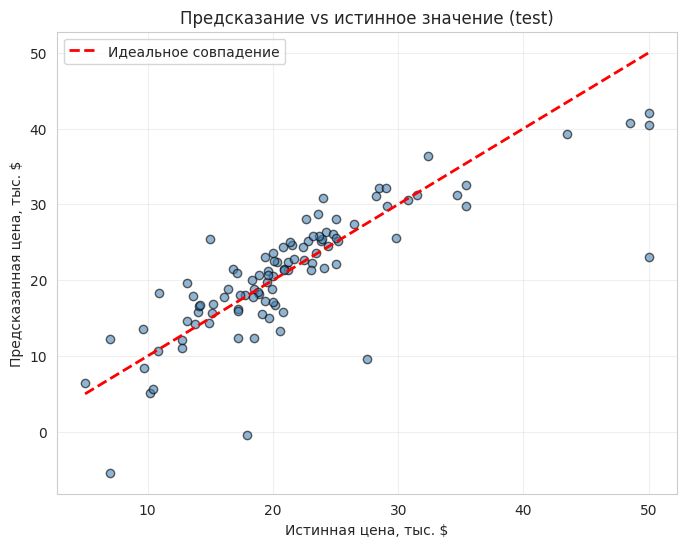

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_2, alpha=0.6, color="steelblue",
            edgecolor="black")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=2, label="Идеальное совпадение")
plt.title("Предсказание vs истинное значение (test)")
plt.xlabel("Истинная цена, тыс. $")
plt.ylabel("Предсказанная цена, тыс. $")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

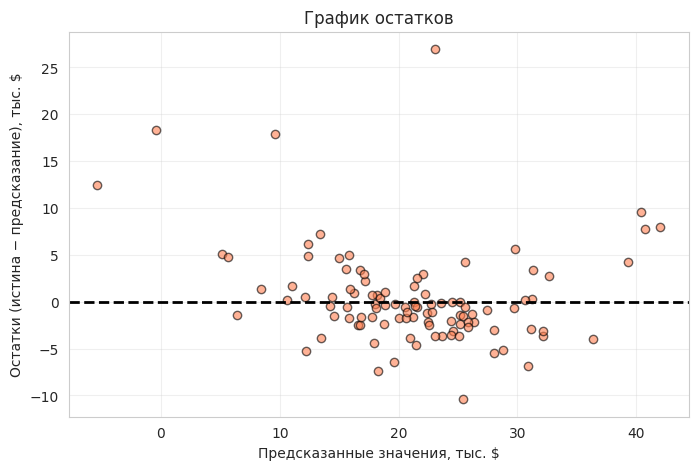

In [32]:
residuals = y_test - y_test_pred_2

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred_2, residuals, alpha=0.6, color="coral",
            edgecolor="black")
plt.axhline(0, color="black", linestyle="--", linewidth=2)
plt.title("График остатков")
plt.xlabel("Предсказанные значения, тыс. $")
plt.ylabel("Остатки (истина − предсказание), тыс. $")
plt.grid(alpha=0.3)
plt.show()

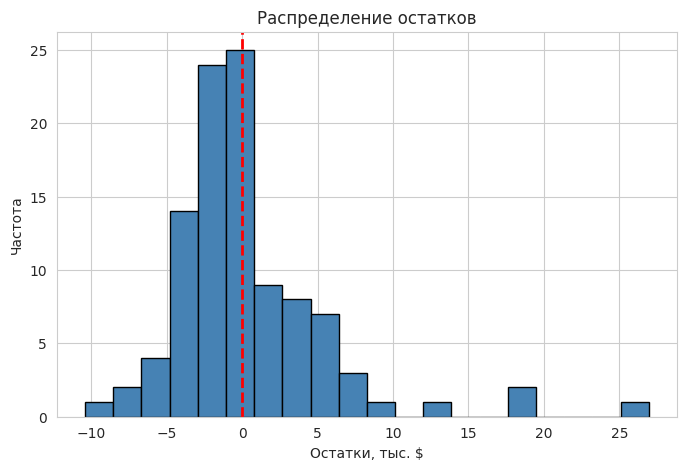

Среднее остатков: 0.3900 тыс. $
Стд. отклонение: 5.1836 тыс. $


In [33]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, color="steelblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--", linewidth=2)
plt.title("Распределение остатков")
plt.xlabel("Остатки, тыс. $")
plt.ylabel("Частота")
plt.show()

print(f"Среднее остатков: {residuals.mean():.4f} тыс. $")
print(f"Стд. отклонение: {residuals.std():.4f} тыс. $")

### Что видно

- Точки на графике «предсказание vs истина» вокруг красной линии,
  но крупные дома (> 40 тыс. $) модель **недооценивает**.
- На графике остатков видна **слабая «воронка»**: разброс остатков
  растёт с ростом предсказания. Признак гетероскедастичности.
- Распределение остатков близко к нормальному, центр около 0.

**Вывод:** линейная модель адекватна, но крупные дома предсказывает плохо.

## 5. Итоговый отчёт

### Финальный набор признаков

**Признаки:** все, кроме `RAD`
**Убран:** `RAD` (VIF = 7.4)
**Целевая:** `MEDV`

### Обоснование

1. **Мультиколлинеарность:** `RAD` имел VIF = 7.4 (связь с `TAX`).
2. **Сравнение метрик:** удаление `RAD` не ухудшило модель.
3. **Принцип простоты:** меньше признаков — меньше риск переобучения.

### Метрики финальной модели (test)

- **MAE = 3.52** → ошибка **$3,520** в среднем.
- **RMSE = 4.71** → типичная ошибка **$4,710**; RMSE > MAE,
  значит есть крупные ошибки.
- **R² = 0.69** → модель объясняет **69%** разброса цен.

### Что можно улучшить

1. Логарифмировать `MEDV` (распределение скошено).
2. Попробовать нелинейные модели (Random Forest, Gradient Boosting).